# Binary Logistic Regression

We’re now going to cover an alternate output layer option, where each neuron separately represents two classes. 0 for one of the classes, and a 1 for the other. A model with this type of output layer is called ​ binary logistic regression. This single neuron could represent two classes like ​ cat​ vs. dog​, but it could also represent ​cat​ vs. ​not cat​ or any combination of 2 classes

Binary logistic regression is a regressor type of algorithm, which will differ as we’ll use a **sigmoid** activation function for the output layer rather than **softmax**, and **binary cross-entropy** rather than **categorical cross-entropy** for calculating loss.

In [1]:
# imports
import math
import random
import numpy as np 
import matplotlib.pyplot as plt 
import nnfs
from nnfs.datasets import spiral_data

## Sigmoid Activation Function 

$$\sigma_{i,j} = \frac{1}{1 + e^{-z_{i,j}}}$$

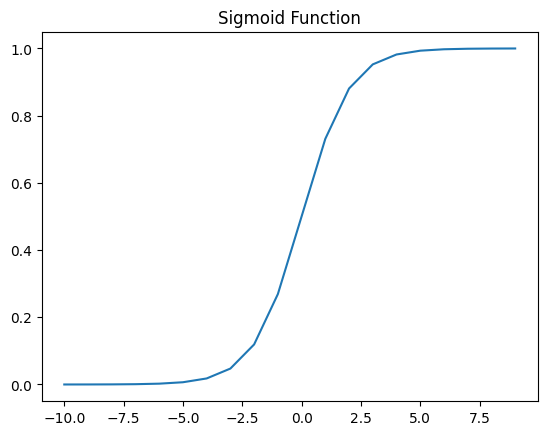

In [6]:
# Plotting sigmoid function
i = np.arange(-10, 10)
sigmoid_fn = 1 / (1 + np.e ** -i)
plt.plot(i, sigmoid_fn)
plt.title("Sigmoid Function")
plt.show()

# Derivation of Sigmoid Function

$$\frac{\partial \sigma}{\partial z_{i,j}} = \sigma_{i,j}\left(1 - \sigma_{i,j}\right)$$

---

### Full Derivation

$$\frac{\partial \sigma}{\partial z} = \frac{\partial}{\partial z} \left[ \frac{1}{1 + e^{-z}} \right] = \frac{\partial}{\partial z} \left[ (1 + e^{-z})^{-1} \right] = -(1 + e^{-z})^{-2} \cdot \frac{\partial}{\partial z}\left[1 + e^{-z}\right] = \frac{e^{-z}}{(1 + e^{-z})^2}$$

$$= \frac{(1 + e^{-z}) - 1}{(1 + e^{-z})^2} = \frac{1}{1 + e^{-z}} - \frac{1}{(1 + e^{-z})^2} = \frac{1}{1+e^{-z}}\left(1 - \frac{1}{1+e^{-z}}\right) = \boxed{\sigma(z)(1 - \sigma(z))}$$



$$\frac{\partial L}{\partial z} = \underbrace{\frac{\partial L}{\partial \hat{y}}}_{\text{from loss layer}} \cdot \underbrace{\sigma(z)(1 - \sigma(z))}_{\text{local derivative we derived}}$$

# Sigmoid as a Class `Activation_Sigmoid`

In [7]:
class Activation_Sigmoid:
    def forward(self, inputs):
        self.inputs = inputs
        self.output = 1 / (1 + np.exp(-inputs))
    
    def backward(self, dvalues):
        self.dinputs = dvalues * (1 - self.output) * self.output

# Binary Cross Entropy Loss `Loss_BinaryCrossEntropy`

$$L = -\frac{1}{N}\sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

### Derivation

$$\frac{\partial L}{\partial \hat{y}_{i,j}} = -\frac{1}{N \cdot M}\left[\frac{y_{i,j}}{\hat{y}_{i,j}} - \frac{1 - y_{i,j}}{1 - \hat{y}_{i,j}}\right]$$

$$\frac{\partial L}{\partial \hat{y}_{i,j}} = 
\underbrace{-\left[\frac{y_{i,j}}{\hat{y}_{i,j}} - \frac{1-y_{i,j}}{1-\hat{y}_{i,j}}\right]}_{\text{gradient per output}} 
\cdot \underbrace{\frac{1}{M}}_{\texttt{/ outputs}} 
\cdot \underbrace{\frac{1}{N}}_{\texttt{/ samples}}$$

In [13]:
class Loss: 
    def regularization_loss(self, layer):
        regularization_loss = 0

        # integrate l1 regularizer here
        if layer.weight_regularizer_l1 > 0:
            regularization_loss += layer.weight_regularizer_l1 * np.sum(np.abs(layer.weights))
        if layer.bias_regularizer_l1 > 0:
            regularization_loss += layer.bias_regularizer_l1 * np.sum(np.abs(layer.biases))

        # integrate l2 regularizer here
        if layer.weight_regularizer_l2 > 0:
            regularization_loss += layer.weight_regularizer_l2 * np.sum(layer.weights ** 2)
        if layer.bias_regularizer_l2 > 0:
            regularization_loss += layer.bias_regularizer_l2 * np.sum(layer.biases ** 2)
        
        return regularization_loss
    
    def calculate(self, output, y):
        sample_losses = self.forward(output, y)
        loss_mean = np.mean(sample_losses)
        return loss_mean

class Loss_BinaryCrossEntropy(Loss):
    # Forward pass
    def forward(self, y_pred, y_true):
        # Clip data to prevent divsion by 0
        y_pred_clipped = np.clip(y_pred, 1e-7, 1-1e-7)
        sample_losses = - (y_true * np.log(y_pred_clipped) + (1 - y_true) * np.log(1 - y_pred_clipped))
        
        loss_mean = np.mean(sample_losses, axis=-1)
        return loss_mean

    # Backward pass 
    def backward(self, dvalues, y_true): 
        # Number of samples 
        samples = len(dvalues) 
        # Number of outputs in every sample 
        # We'll use the first sample to count them 
        outputs = len(dvalues[0]) 
 
        # Clip data to prevent division by 0 
        clipped_dvalues = np.clip(dvalues, 1e-7, 1 - 1e-7) 
 
        # Calculate gradient 
        self.dinputs = -(y_true / clipped_dvalues - (1 - y_true) / (1 - clipped_dvalues)) / outputs 
        # Normalize gradient 
        self.dinputs = self.dinputs / samples         

# Initialize Current Code

In [ ]:
class Layer_Dense:
    def __init__(self, n_inputs, n_neurons,
                 weight_regularizer_l1=0, bias_regularizer_l1=0,
                 weight_regularizer_l2=0, bias_regularizer_l2=0):
        self.weights = 0.10 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

        self.weight_regularizer_l1 = weight_regularizer_l1
        self.bias_regularizer_l1 = bias_regularizer_l1
        self.weight_regularizer_l2 = weight_regularizer_l2
        self.bias_regularizer_l2 = bias_regularizer_l2        

    def forward(self, inputs):
        self.inputs = inputs 
        self.output = np.dot(inputs, self.weights) + self.biases

    def backward(self, dvalues):
        self.dweights = np.dot(self.inputs.T, dvalues) 
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)         

        if self.weight_regularizer_l1 > 0:
            dL1 = np.ones_like(self.weights)
            dL1[self.weights < 0] = -1
            self.dweights += self.weight_regularizer_l1 * dL1
        if self.bias_regularizer_l1 > 0:
            dL1 = np.ones_like(self.biases)
            dL1[self.biases < 0] = -1
            self.dbiases += self.bias_regularizer_l1 * dL1

        if self.weight_regularizer_l2 > 0:
            self.dweights += 2 * self.weight_regularizer_l2 * self.weights
        if self.bias_regularizer_l2 > 0:
            self.dbiases += 2 * self.bias_regularizer_l2 * self.biases

        self.dinputs = np.dot(dvalues, self.weights.T)

class Activation_ReLU: 
    def forward(self, inputs): 
        self.inputs = inputs 
        self.output = np.maximum(0, inputs) 

    def backward(self, dvalues): 
        self.dinputs = dvalues.copy() 
        self.dinputs[self.inputs <= 0] = 0 

class Loss: 
    def regularization_loss(self, layer):
        regularization_loss = 0

        # integrate l1 regularizer here
        if layer.weight_regularizer_l1 > 0:
            regularization_loss += layer.weight_regularizer_l1 * np.sum(np.abs(layer.weights))
        if layer.bias_regularizer_l1 > 0:
            regularization_loss += layer.bias_regularizer_l1 * np.sum(np.abs(layer.biases))

        # integrate l2 regularizer here
        if layer.weight_regularizer_l2 > 0:
            regularization_loss += layer.weight_regularizer_l2 * np.sum(layer.weights ** 2)
        if layer.bias_regularizer_l2 > 0:
            regularization_loss += layer.bias_regularizer_l2 * np.sum(layer.biases ** 2)
        
        return regularization_loss

    def calculate(self, output, y): 
        sample_losses = self.forward(output, y) 
        data_loss = np.mean(sample_losses) 
        return data_loss 
    
class Loss_CategoricalCrossentropy(Loss): 
    def forward(self, y_pred, y_true): 
        samples = len(y_pred) 
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7) 
        if len(y_true.shape) == 1: 
            correct_confidences = y_pred_clipped[range(samples), y_true] 
        elif len(y_true.shape) == 2: 
            correct_confidences = np.sum(y_pred_clipped * y_true, axis=1) 
 
        negative_log_likelihoods = -np.log(correct_confidences) 
        return negative_log_likelihoods 
 
    def backward(self, dvalues, y_true): 
        samples = len(dvalues) 
        labels = len(dvalues[0]) 

        if len(y_true.shape) == 1: 
            y_true = np.eye(labels)[y_true] 
 
        self.dinputs = -y_true / dvalues 
        self.dinputs = self.dinputs / samples 

class Activation_Softmax: 
    def forward(self, inputs): 
        self.inputs = inputs 
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True)) 
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True) 
        self.output = probabilities 

    def backward(self, dvalues): 
        self.dinputs = np.empty_like(dvalues) 
 
        for index, (single_output, single_dvalues) in enumerate(zip(self.output, dvalues)): 
            single_output = single_output.reshape(-1, 1) 
            jacobian_matrix = np.diagflat(single_output) - np.dot(single_output, single_output.T) 

            self.dinputs[index] = np.dot(jacobian_matrix, 
                                         single_dvalues) 
 
class Activation_Softmax_Loss_CategoricalCrossentropy(): 
    def __init__(self): 
        self.activation = Activation_Softmax() 
        self.loss = Loss_CategoricalCrossentropy() 
 
    def forward(self, inputs, y_true): 
        self.activation.forward(inputs) 
        self.output = self.activation.output 
        return self.loss.calculate(self.output, y_true) 
 
    def backward(self, dvalues, y_true): 
 
        samples = len(dvalues) 
 
        if len(y_true.shape) == 2: 
            y_true = np.argmax(y_true, axis=1) 
 
        self.dinputs = dvalues.copy() 
        self.dinputs[range(samples), y_true] -= 1 
        self.dinputs = self.dinputs / samples 

class Optimizer_Adam: 
    def __init__(self, learning_rate=0.001, decay=0., epsilon=1e-7, beta_1=0.9, beta_2=0.999): 
        self.learning_rate = learning_rate 
        self.current_learning_rate = learning_rate 
        self.decay = decay 
        self.iterations = 0 
        self.epsilon = epsilon 
        self.beta_1 = beta_1 
        self.beta_2 = beta_2 
 
    def pre_update_params(self): 
        if self.decay: 
            self.current_learning_rate = self.learning_rate * (1. / (1. + self.decay * self.iterations)) 
 
    def update_params(self, layer): 
 
        if not hasattr(layer, 'weight_cache'): 
            layer.weight_momentums = np.zeros_like(layer.weights) 
            layer.weight_cache = np.zeros_like(layer.weights) 
            layer.bias_momentums = np.zeros_like(layer.biases) 
            layer.bias_cache = np.zeros_like(layer.biases) 
 
        layer.weight_momentums = self.beta_1 * layer.weight_momentums + (1 - self.beta_1) * layer.dweights 
        layer.bias_momentums = self.beta_1 * layer.bias_momentums + (1 - self.beta_1) * layer.dbiases 

        weight_momentums_corrected = layer.weight_momentums / (1 - self.beta_1 ** (self.iterations + 1)) 
        bias_momentums_corrected = layer.bias_momentums / (1 - self.beta_1 ** (self.iterations + 1)) 

        layer.weight_cache = self.beta_2 * layer.weight_cache + (1 - self.beta_2) * layer.dweights**2 
        layer.bias_cache = self.beta_2 * layer.bias_cache + (1 - self.beta_2) * layer.dbiases**2 

        weight_cache_corrected = layer.weight_cache / (1 - self.beta_2 ** (self.iterations + 1)) 
        bias_cache_corrected = layer.bias_cache / (1 - self.beta_2 ** (self.iterations + 1)) 
 
        layer.weights += -self.current_learning_rate * weight_momentums_corrected / (np.sqrt(weight_cache_corrected) + self.epsilon) 
        layer.biases += -self.current_learning_rate * bias_momentums_corrected / (np.sqrt(bias_cache_corrected) + self.epsilon) 
 
    def post_update_params(self): 
        self.iterations += 1 

    

# Implementing BLR and BCE Loss

In [30]:
decay = 5e-7
learning_rate = 0.001
n_epochs = 10_000

# track history for graphing
loss_history, accuracy_history, learning_rate_history = [], [], []

# 2 classes with binary output
X, y = spiral_data(samples=100, classes=2)

# reshape it to 1D column vector shape: (n, 1)
y = y.reshape(-1, 1)

dense1 = Layer_Dense(2, 64, weight_regularizer_l2=5e-4, bias_regularizer_l2=5e-4)
activation1 = Activation_ReLU()
dense2 = Layer_Dense(64, 1)

# use our sigmoid and BCE for logistic regression task
activation2 = Activation_Sigmoid()
loss_function = Loss_BinaryCrossEntropy()

optimizer = Optimizer_Adam(learning_rate=learning_rate, decay=decay)

for epoch in range(n_epochs):
    dense1.forward(X)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)

    # pass in dense2 outputs to sigmoid method forward
    activation2.forward(dense2.output)

    data_loss = loss_function.calculate(activation2.output, y)

    # get regularization loss
    regularization_loss = loss_function.regularization_loss(dense1) + loss_function.regularization_loss(dense2)

    # total loss
    loss = data_loss + regularization_loss
    
    predictions = (activation2.output > 0.5) * 1
    accuracy = np.mean(predictions == y)

    if epoch % (n_epochs / 10) == 0:
        print(f'epoch: {epoch}, ' + 
              f'acc: {accuracy:.3f}, '+ 
              f'loss: {loss:.3f} (' + 
              f'data_loss: {data_loss:.3f}, ' + 
              f'reg_loss: {regularization_loss:.3f}), ' + 
              f'lr: {optimizer.current_learning_rate}')
        
    loss_function.backward(activation2.output, y)
    activation2.backward(loss_function.dinputs)
    dense2.backward(activation2.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    # update weights and biases
    optimizer.pre_update_params()
    optimizer.update_params(dense1)
    optimizer.update_params(dense2)
    optimizer.post_update_params()

    loss_history.append(loss)
    accuracy_history.append(accuracy)
    learning_rate_history.append(optimizer.current_learning_rate)


epoch: 0, acc: 0.560, loss: 0.693 (data_loss: 0.692, reg_loss: 0.001), lr: 0.001
epoch: 1000, acc: 0.760, loss: 0.564 (data_loss: 0.547, reg_loss: 0.017), lr: 0.000999500749375687
epoch: 2000, acc: 0.875, loss: 0.425 (data_loss: 0.369, reg_loss: 0.056), lr: 0.0009990014980027463
epoch: 3000, acc: 0.955, loss: 0.341 (data_loss: 0.262, reg_loss: 0.079), lr: 0.000998502745133672
epoch: 4000, acc: 0.965, loss: 0.287 (data_loss: 0.198, reg_loss: 0.089), lr: 0.0009980044900222008
epoch: 5000, acc: 0.965, loss: 0.253 (data_loss: 0.167, reg_loss: 0.086), lr: 0.000997506731923557
epoch: 6000, acc: 0.965, loss: 0.227 (data_loss: 0.147, reg_loss: 0.080), lr: 0.0009970094700944517
epoch: 7000, acc: 0.965, loss: 0.206 (data_loss: 0.132, reg_loss: 0.074), lr: 0.000996512703793076
epoch: 8000, acc: 0.970, loss: 0.188 (data_loss: 0.119, reg_loss: 0.069), lr: 0.0009960164322790998
epoch: 9000, acc: 0.975, loss: 0.174 (data_loss: 0.109, reg_loss: 0.065), lr: 0.000995520654813666


# Validate model

In [31]:
X_test, y_test = spiral_data(samples=100, classes=2)

y_test = y_test.reshape(-1, 1)

dense1.forward(X_test)
activation1.forward(dense1.output) 
dense2.forward(activation1.output) 
activation2.forward(dense2.output) 
loss = loss_function.calculate(activation2.output, y_test) 

# Calculate accuracy from output of activation2 and targets 
# Part in the brackets returns a binary mask - array consisting of 
# True/False values, multiplying it by 1 changes it into array 
# of 1s and 0s 
predictions = (activation2.output > 0.5) * 1 
accuracy = np.mean(predictions==y_test) 
print(f'validation, acc:  {accuracy:.3f}, loss:  {loss:.3f}') 

validation, acc:  0.915, loss:  0.364


# Initialize Graph Functions

In [37]:
def plot_decision_boundary(model_layers, X, y, resolution=0.02):
    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, resolution),
        np.arange(y_min, y_max, resolution)
    )
    
    # Flatten mesh and predict
    Z_input = np.c_[xx.ravel(), yy.ravel()]
    
    # Forward pass through network
    dense1.forward(Z_input)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    loss_function.forward(dense2.output, np.zeros((len(Z_input), 3)))
    
    # Get predictions
    Z = np.argmax(loss_function.output, axis=1).reshape(xx.shape)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Contourf for decision boundaries
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis', levels=2)
    
    # Scatter plot for actual data
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y if len(y.shape) == 1 else np.argmax(y, axis=1),
                        cmap='viridis', edgecolors='k', s=50, alpha=0.7)
    
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title('Neural Network Decision Boundaries')
    plt.colorbar(scatter, ax=ax, label='Class')
    plt.tight_layout()
    plt.show()

# Graph Data

Final Values: Loss 0.1617984956264305 Accuracy 0.975 Learning Rate 0.0009950253706593885
Learning Rate 0.001 Decay 5e-07


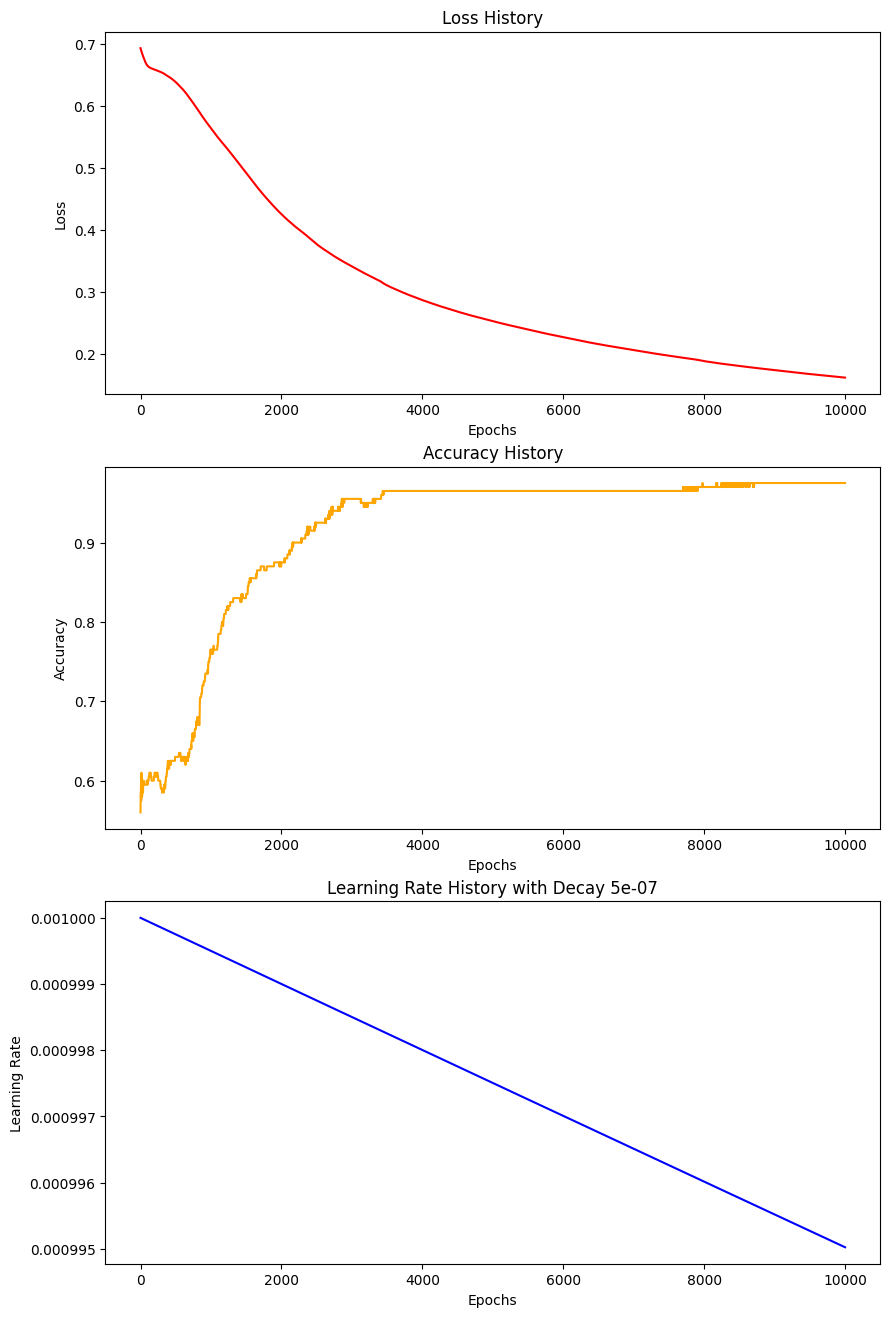

In [38]:
fig, axes = plt.subplots(nrows=3, figsize=(10, 16))

axes[0].set_title("Loss History")
axes[0].plot(loss_history, color="red")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")

axes[1].set_title("Accuracy History")
axes[1].plot(accuracy_history, color="orange")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")

axes[2].set_title(f"Learning Rate History with Decay {decay}")
axes[2].plot(learning_rate_history, color="blue")
axes[2].set_xlabel("Epochs")
axes[2].set_ylabel("Learning Rate")

print(f"Final Values: Loss {loss_history[-1]} Accuracy {accuracy_history[-1]} Learning Rate {learning_rate_history[-1]}")
print(f"Learning Rate {learning_rate} Decay {decay}")
